
# 02 — Data Cleaning and Validation

**Project:** Product Pulse

This notebook validates and cleans the four datasets used by Product Pulse:

- **Retailrocket** — behavioral events and product metadata
- **Online Retail II** — transactions and revenue
- **Cookie Cats** — randomized A/B experiment
- **Criteo Uplift** — treatment/control uplift experiment

### Goals

1. Validate expected files and schemas.
2. Quantify duplicates, missing keys, invalid values, and other data-quality issues.
3. Apply documented cleaning rules.
4. Save cleaned data to `data/processed/02_cleaned/`.
5. Save **only compact notebook results** to `results/02_data_cleaning_and_validation/`.

> Raw data is never overwritten.


In [1]:
import pandas as pd
import pyarrow as pa

from pandas.compat import (
    pa_version_under14p1,
    PYARROW_INSTALLED,
)

print("Pandas:", pd.__version__)
print("PyArrow:", pa.__version__)
print("PyArrow installed:", PYARROW_INSTALLED)
print("PyArrow < 14.0.1:", pa_version_under14p1)

Pandas: 3.0.5
PyArrow: 25.0.0
PyArrow installed: True
PyArrow < 14.0.1: False


In [2]:
! pip install pyarrow

In [3]:
import sys
import site
import importlib.util

print("Python:")
print(sys.executable)

print("\nSite packages:")
print(site.getsitepackages())

print("\nPyArrow lookup:")
print(importlib.util.find_spec("pyarrow"))

Python:
/opt/anaconda3/envs/adaptive-regime/bin/python

Site packages:
['/opt/anaconda3/envs/adaptive-regime/lib/python3.12/site-packages']

PyArrow lookup:
ModuleSpec(name='pyarrow', loader=<_frozen_importlib_external.SourceFileLoader object at 0x10675aff0>, origin='/opt/anaconda3/envs/adaptive-regime/lib/python3.12/site-packages/pyarrow/__init__.py', submodule_search_locations=['/opt/anaconda3/envs/adaptive-regime/lib/python3.12/site-packages/pyarrow'])


In [4]:
test_df = pd.DataFrame({
    "a": [1, 2, 3],
    "b": ["x", "y", "z"]
})

test_df.to_parquet(
    "/tmp/productpulse_test.parquet",
    index=False
)

pd.read_parquet("/tmp/productpulse_test.parquet")

,a,b
0,1,x
1,2,y
2,3,z


In [5]:

from pathlib import Path
import shutil
import warnings

import numpy as np
import pandas as pd
import pyarrow
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

warnings.filterwarnings("ignore", category=FutureWarning)

# ------------------------------------------------------------
# Project paths
# ------------------------------------------------------------

PROJECT_ROOT = Path.home() / "Desktop" / "resume_projects" / "ProductPulse"

raw_candidates = [
    PROJECT_ROOT / "data" / "raw",
    PROJECT_ROOT / "Data" / "raw",
]

RAW_DIR = next((p for p in raw_candidates if p.exists()), raw_candidates[0])

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "02_cleaned"
RESULTS_DIR = PROJECT_ROOT / "results" / "02_data_cleaning_and_validation"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT :", PROJECT_ROOT)
print("RAW_DIR      :", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("RESULTS_DIR  :", RESULTS_DIR)

if not RAW_DIR.exists():
    raise FileNotFoundError(
        "Raw-data directory was not found.\nExpected one of:\n"
        + "\n".join(str(p) for p in raw_candidates)
    )


PROJECT_ROOT : /Users/noopur/Desktop/resume_projects/ProductPulse
RAW_DIR      : /Users/noopur/Desktop/resume_projects/ProductPulse/data/raw
PROCESSED_DIR: /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/02_cleaned
RESULTS_DIR  : /Users/noopur/Desktop/resume_projects/ProductPulse/results/02_data_cleaning_and_validation



## 1. Input file validation

Before cleaning anything, confirm that the files discovered in Notebook 01 are still present.


In [6]:

EXPECTED_FILES = {
    "cookie_cats": RAW_DIR / "cookie_cats" / "cookie_cats.csv",
    "criteo": RAW_DIR / "criteo" / "criteo-uplift-v2.1.csv.gz",
    "online_retail": RAW_DIR / "online_retail" / "online_retail_II.xlsx",
    "retailrocket_category_tree": RAW_DIR / "retailrocket" / "category_tree.csv",
    "retailrocket_events": RAW_DIR / "retailrocket" / "events.csv",
    "retailrocket_properties_1": RAW_DIR / "retailrocket" / "item_properties_part1.csv",
    "retailrocket_properties_2": RAW_DIR / "retailrocket" / "item_properties_part2.csv",
}

file_check = pd.DataFrame(
    [
        {
            "dataset": name,
            "path": str(path.relative_to(PROJECT_ROOT)) if path.exists() else str(path),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / (1024 ** 2), 2) if path.exists() else np.nan,
        }
        for name, path in EXPECTED_FILES.items()
    ]
)

display(file_check)

missing_files = file_check.loc[~file_check["exists"], "dataset"].tolist()
if missing_files:
    raise FileNotFoundError(f"Missing expected raw files: {missing_files}")


,dataset,path,exists,size_mb
0,cookie_cats,data/raw/cookie_cats/cookie_cats.csv,True,2.58
1,criteo,data/raw/criteo/criteo-uplift-v2.1.csv.gz,True,297.00
2,online_retail,data/raw/online_retail/online_retail_II.xlsx,True,43.51
3,retailrocket_category_tree,data/raw/retailrocket/category_tree.csv,True,0.01
4,retailrocket_events,data/raw/retailrocket/events.csv,True,89.87
5,retailrocket_properties_1,data/raw/retailrocket/item_properties_part1.csv,True,461.88
6,retailrocket_properties_2,data/raw/retailrocket/item_properties_part2.csv,True,389.99



## 2. Cleaning helpers

The notebook records important quality checks in compact summary tables.

Large cleaned datasets are written to Parquet under `data/processed/02_cleaned/`; they are **not** copied into the `results/` folder.


In [7]:

validation_records = []
cleaning_records = []
processed_records = []

def add_validation(dataset, check, count, note=""):
    validation_records.append(
        {
            "dataset": dataset,
            "check": check,
            "count": int(count) if pd.notna(count) else np.nan,
            "note": note,
        }
    )

def add_cleaning_summary(dataset, raw_rows, clean_rows, notes=""):
    removed = int(raw_rows - clean_rows)
    cleaning_records.append(
        {
            "dataset": dataset,
            "raw_rows": int(raw_rows),
            "clean_rows": int(clean_rows),
            "rows_removed": removed,
            "pct_removed": round((removed / raw_rows * 100), 4) if raw_rows else 0.0,
            "pct_retained": round((clean_rows / raw_rows * 100), 4) if raw_rows else 0.0,
            "notes": notes,
        }
    )

def record_output(dataset, path, description):
    processed_records.append(
        {
            "dataset": dataset,
            "output": str(Path(path).relative_to(PROJECT_ROOT)),
            "description": description,
        }
    )

def write_parquet(df, path):
    try:
        df.to_parquet(path, index=False)
    except ImportError as exc:
        raise ImportError(
            "Parquet support requires pyarrow. "
            "Run `%pip install pyarrow` once in this environment and rerun the notebook."
        ) from exc

def coerce_binary(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype("Int8")

    mapping = {
        True: 1, False: 0,
        "True": 1, "False": 0,
        "true": 1, "false": 0,
        "TRUE": 1, "FALSE": 0,
        "1": 1, "0": 0,
        1: 1, 0: 0,
    }

    mapped = series.map(mapping)
    numeric = pd.to_numeric(series, errors="coerce")
    return mapped.fillna(numeric).astype("Int8")



# 3. Cookie Cats

Cleaning rules:

- `userid` must be present.
- `version` must be `gate_30` or `gate_40`.
- `sum_gamerounds` must be numeric and non-negative.
- `retention_1` and `retention_7` must be valid binary values.
- Exact duplicate rows are removed.
- Duplicate user IDs are quantified; after validation, one record per user is retained.


In [8]:
! pip install pyarrow

In [9]:

cookie_path = EXPECTED_FILES["cookie_cats"]
cookie = pd.read_csv(cookie_path)

print("Shape:", cookie.shape)
display(cookie.head())

expected_cookie_cols = {
    "userid", "version", "sum_gamerounds", "retention_1", "retention_7"
}

missing_cols = expected_cookie_cols - set(cookie.columns)
if missing_cols:
    raise ValueError(f"Cookie Cats missing expected columns: {sorted(missing_cols)}")

cookie_raw_rows = len(cookie)

add_validation("Cookie Cats", "exact_duplicate_rows", cookie.duplicated().sum())
add_validation("Cookie Cats", "duplicate_userids", cookie["userid"].duplicated().sum())
add_validation("Cookie Cats", "missing_userid", cookie["userid"].isna().sum())
add_validation(
    "Cookie Cats",
    "invalid_version",
    (~cookie["version"].isin(["gate_30", "gate_40"])).sum(),
)
add_validation(
    "Cookie Cats",
    "missing_sum_gamerounds",
    cookie["sum_gamerounds"].isna().sum(),
)

cookie_clean = cookie.drop_duplicates().copy()

cookie_clean["userid"] = pd.to_numeric(cookie_clean["userid"], errors="coerce")
cookie_clean["sum_gamerounds"] = pd.to_numeric(
    cookie_clean["sum_gamerounds"], errors="coerce"
)
cookie_clean["retention_1"] = coerce_binary(cookie_clean["retention_1"])
cookie_clean["retention_7"] = coerce_binary(cookie_clean["retention_7"])

valid_mask = (
    cookie_clean["userid"].notna()
    & cookie_clean["version"].isin(["gate_30", "gate_40"])
    & cookie_clean["sum_gamerounds"].notna()
    & cookie_clean["sum_gamerounds"].ge(0)
    & cookie_clean["retention_1"].isin([0, 1])
    & cookie_clean["retention_7"].isin([0, 1])
)

cookie_clean = cookie_clean.loc[valid_mask].copy()
cookie_clean = cookie_clean.drop_duplicates(subset=["userid"], keep="first")

cookie_clean["userid"] = cookie_clean["userid"].astype("int64")
cookie_clean["sum_gamerounds"] = cookie_clean["sum_gamerounds"].astype("int64")

cookie_output = PROCESSED_DIR / "cookie_cats_clean.parquet"
write_parquet(cookie_clean, cookie_output)

add_cleaning_summary(
    "Cookie Cats",
    cookie_raw_rows,
    len(cookie_clean),
    "Removed exact duplicates, invalid experiment rows, and repeated userid records.",
)
record_output(
    "Cookie Cats",
    cookie_output,
    "Clean A/B experiment table.",
)

print("Clean shape:", cookie_clean.shape)
display(cookie_clean.head())


Shape: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


Clean shape: (90189, 5)


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,0,0
1,337,gate_30,38,1,0
2,377,gate_40,165,1,0
3,483,gate_40,1,0,0
4,488,gate_40,179,1,1


In [10]:
import pandas as pd
import pyarrow as pa
import sys

print("Python :", sys.executable)
print("Pandas :", pd.__version__)
print("PyArrow:", pa.__version__)
print("PyArrow path:", pa.__file__)

Python : /opt/anaconda3/envs/adaptive-regime/bin/python
Pandas : 3.0.5
PyArrow: 25.0.0
PyArrow path: /opt/anaconda3/envs/adaptive-regime/lib/python3.12/site-packages/pyarrow/__init__.py


In [11]:
! pip install pyarrow

In [12]:
import sys
print(sys.executable)

/opt/anaconda3/envs/adaptive-regime/bin/python



# 4. Online Retail II

Cleaning rules for the downstream sales/customer analytics table:

- Combine all workbook sheets.
- Standardize column names.
- Parse dates and numeric fields.
- Remove exact duplicate rows.
- Require invoice, stock code, date, quantity, and price.
- Exclude cancelled invoices from the clean sales table.
- Keep only `Quantity > 0` and `Price > 0`.
- Preserve rows with missing `CustomerID` because they can still contribute to product/revenue analysis.
- Add `Revenue = Quantity × Price`.

Cancelled/return records are quantified before filtering so the cleaning decision remains transparent.


In [13]:

retail_path = EXPECTED_FILES["online_retail"]

retail_book = pd.read_excel(
    retail_path,
    sheet_name=None,
    engine="openpyxl",
)

print("Sheets:", list(retail_book.keys()))

retail_frames = []

for sheet_name, frame in retail_book.items():
    frame = frame.copy()
    frame["source_sheet"] = sheet_name
    retail_frames.append(frame)

online_retail = pd.concat(retail_frames, ignore_index=True)

online_retail.columns = [
    str(c).strip().replace(" ", "") for c in online_retail.columns
]

expected_retail_cols = {
    "Invoice",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "Price",
    "CustomerID",
    "Country",
}

missing_cols = expected_retail_cols - set(online_retail.columns)
if missing_cols:
    raise ValueError(
        f"Online Retail II missing expected columns: {sorted(missing_cols)}"
    )

online_raw_rows = len(online_retail)

online_retail["Invoice"] = online_retail["Invoice"].astype("string").str.strip()
online_retail["StockCode"] = online_retail["StockCode"].astype("string").str.strip()
online_retail["Description"] = online_retail["Description"].astype("string").str.strip()
online_retail["Country"] = online_retail["Country"].astype("string").str.strip()

online_retail["Quantity"] = pd.to_numeric(
    online_retail["Quantity"], errors="coerce"
)
online_retail["Price"] = pd.to_numeric(
    online_retail["Price"], errors="coerce"
)
online_retail["CustomerID"] = pd.to_numeric(
    online_retail["CustomerID"], errors="coerce"
).astype("Int64")
online_retail["InvoiceDate"] = pd.to_datetime(
    online_retail["InvoiceDate"], errors="coerce"
)

cancelled_mask = online_retail["Invoice"].str.upper().str.startswith("C", na=False)

add_validation("Online Retail II", "exact_duplicate_rows", online_retail.duplicated().sum())
add_validation("Online Retail II", "missing_invoice", online_retail["Invoice"].isna().sum())
add_validation("Online Retail II", "missing_stockcode", online_retail["StockCode"].isna().sum())
add_validation("Online Retail II", "missing_description", online_retail["Description"].isna().sum())
add_validation("Online Retail II", "missing_customerid", online_retail["CustomerID"].isna().sum())
add_validation("Online Retail II", "invalid_invoice_date", online_retail["InvoiceDate"].isna().sum())
add_validation("Online Retail II", "cancelled_invoice_rows", cancelled_mask.sum())
add_validation("Online Retail II", "quantity_le_0", online_retail["Quantity"].le(0).sum())
add_validation("Online Retail II", "price_le_0", online_retail["Price"].le(0).sum())

online_clean = online_retail.drop_duplicates().copy()

valid_sales_mask = (
    online_clean["Invoice"].notna()
    & online_clean["StockCode"].notna()
    & online_clean["InvoiceDate"].notna()
    & online_clean["Quantity"].notna()
    & online_clean["Price"].notna()
    & ~online_clean["Invoice"].str.upper().str.startswith("C", na=False)
    & online_clean["Quantity"].gt(0)
    & online_clean["Price"].gt(0)
)

online_clean = online_clean.loc[valid_sales_mask].copy()
online_clean["Revenue"] = online_clean["Quantity"] * online_clean["Price"]

online_output = PROCESSED_DIR / "online_retail_sales_clean.parquet"
write_parquet(online_clean, online_output)

add_cleaning_summary(
    "Online Retail II",
    online_raw_rows,
    len(online_clean),
    "Positive completed sales only; cancellations/returns and invalid sales rows excluded.",
)
record_output(
    "Online Retail II",
    online_output,
    "Clean completed sales transactions with Revenue.",
)

print("Raw shape  :", online_retail.shape)
print("Clean shape:", online_clean.shape)
display(online_clean.head())


Sheets: ['Year 2009-2010', 'Year 2010-2011']
Raw shape  : (1067371, 9)
Clean shape: (1029609, 10)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,source_sheet,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010,30.0



# 5. Retailrocket events and category tree

The event table will drive Product Pulse behavior/funnel analysis.

Cleaning rules:

- `visitorid`, `itemid`, `timestamp`, and `event` are required.
- Valid events are `view`, `addtocart`, and `transaction`.
- Exact duplicates are removed.
- Millisecond timestamps are converted to UTC datetimes.

The category tree is cleaned separately.


In [14]:

events_path = EXPECTED_FILES["retailrocket_events"]
events = pd.read_csv(events_path)

expected_event_cols = {
    "timestamp", "visitorid", "event", "itemid", "transactionid"
}
missing_cols = expected_event_cols - set(events.columns)
if missing_cols:
    raise ValueError(
        f"Retailrocket events missing expected columns: {sorted(missing_cols)}"
    )

events_raw_rows = len(events)

add_validation("Retailrocket Events", "exact_duplicate_rows", events.duplicated().sum())
add_validation("Retailrocket Events", "missing_visitorid", events["visitorid"].isna().sum())
add_validation("Retailrocket Events", "missing_itemid", events["itemid"].isna().sum())
add_validation("Retailrocket Events", "missing_event", events["event"].isna().sum())
add_validation("Retailrocket Events", "missing_timestamp", events["timestamp"].isna().sum())

events_clean = events.drop_duplicates().copy()

events_clean["timestamp"] = pd.to_numeric(events_clean["timestamp"], errors="coerce")
events_clean["visitorid"] = pd.to_numeric(events_clean["visitorid"], errors="coerce")
events_clean["itemid"] = pd.to_numeric(events_clean["itemid"], errors="coerce")
events_clean["transactionid"] = pd.to_numeric(
    events_clean["transactionid"], errors="coerce"
).astype("Int64")
events_clean["event"] = events_clean["event"].astype("string").str.lower().str.strip()

valid_events = {"view", "addtocart", "transaction"}

invalid_event_count = (~events_clean["event"].isin(valid_events)).sum()
add_validation("Retailrocket Events", "invalid_event_name", invalid_event_count)

valid_mask = (
    events_clean["timestamp"].notna()
    & events_clean["visitorid"].notna()
    & events_clean["itemid"].notna()
    & events_clean["event"].isin(valid_events)
)

events_clean = events_clean.loc[valid_mask].copy()

events_clean["visitorid"] = events_clean["visitorid"].astype("int64")
events_clean["itemid"] = events_clean["itemid"].astype("int64")
events_clean["event_time"] = pd.to_datetime(
    events_clean["timestamp"],
    unit="ms",
    utc=True,
    errors="coerce",
)

events_clean = events_clean.loc[events_clean["event_time"].notna()].copy()

events_output = PROCESSED_DIR / "retailrocket_events_clean.parquet"
write_parquet(events_clean, events_output)

add_cleaning_summary(
    "Retailrocket Events",
    events_raw_rows,
    len(events_clean),
    "Removed duplicate/invalid behavioral events and added event_time.",
)
record_output(
    "Retailrocket Events",
    events_output,
    "Clean behavioral event stream.",
)

print("Raw shape  :", events.shape)
print("Clean shape:", events_clean.shape)
display(events_clean.head())


Raw shape  : (2756101, 5)
Clean shape: (2755641, 6)


,timestamp,visitorid,event,itemid,transactionid,event_time
0,1433221332117,257597,view,355908,<NA>,2015-06-02 05:02:12.117000+00:00
1,1433224214164,992329,view,248676,<NA>,2015-06-02 05:50:14.164000+00:00
2,1433221999827,111016,view,318965,<NA>,2015-06-02 05:13:19.827000+00:00
3,1433221955914,483717,view,253185,<NA>,2015-06-02 05:12:35.914000+00:00
4,1433221337106,951259,view,367447,<NA>,2015-06-02 05:02:17.106000+00:00


In [15]:

category_path = EXPECTED_FILES["retailrocket_category_tree"]
category_tree = pd.read_csv(category_path)

expected_category_cols = {"categoryid", "parentid"}
missing_cols = expected_category_cols - set(category_tree.columns)
if missing_cols:
    raise ValueError(
        f"Retailrocket category tree missing expected columns: {sorted(missing_cols)}"
    )

category_raw_rows = len(category_tree)

add_validation(
    "Retailrocket Category Tree",
    "exact_duplicate_rows",
    category_tree.duplicated().sum(),
)
add_validation(
    "Retailrocket Category Tree",
    "missing_categoryid",
    category_tree["categoryid"].isna().sum(),
)

category_clean = category_tree.drop_duplicates().copy()
category_clean["categoryid"] = pd.to_numeric(
    category_clean["categoryid"], errors="coerce"
)
category_clean["parentid"] = pd.to_numeric(
    category_clean["parentid"], errors="coerce"
).astype("Int64")

category_clean = category_clean.loc[
    category_clean["categoryid"].notna()
].copy()

category_clean["categoryid"] = category_clean["categoryid"].astype("int64")

category_output = PROCESSED_DIR / "retailrocket_category_tree_clean.parquet"
write_parquet(category_clean, category_output)

add_cleaning_summary(
    "Retailrocket Category Tree",
    category_raw_rows,
    len(category_clean),
    "Removed duplicates and rows without categoryid.",
)
record_output(
    "Retailrocket Category Tree",
    category_output,
    "Clean category hierarchy.",
)

display(category_clean.head())


,categoryid,parentid
0,1016,213
1,809,169
2,570,9
3,1691,885
4,536,1691



## Retailrocket item properties — chunked cleaning

The two item-property CSVs are much larger than the event table. They are processed in chunks so the notebook does not need to hold the full property history in memory.

The output is a folder of Parquet parts:

`data/processed/02_cleaned/retailrocket_item_properties/`


In [16]:

property_paths = [
    EXPECTED_FILES["retailrocket_properties_1"],
    EXPECTED_FILES["retailrocket_properties_2"],
]

properties_output_dir = PROCESSED_DIR / "retailrocket_item_properties"

if properties_output_dir.exists():
    shutil.rmtree(properties_output_dir)

properties_output_dir.mkdir(parents=True, exist_ok=True)

PROPERTY_CHUNK_SIZE = 500_000

properties_raw_rows = 0
properties_clean_rows = 0
properties_duplicates = 0
properties_missing_itemid = 0
properties_missing_property = 0
properties_invalid_timestamp = 0
part_number = 0

for source_path in property_paths:
    print("Processing:", source_path.name)

    for chunk in pd.read_csv(source_path, chunksize=PROPERTY_CHUNK_SIZE):
        properties_raw_rows += len(chunk)

        expected_property_cols = {"timestamp", "itemid", "property", "value"}
        missing_cols = expected_property_cols - set(chunk.columns)

        if missing_cols:
            raise ValueError(
                f"{source_path.name} missing columns: {sorted(missing_cols)}"
            )

        properties_duplicates += int(chunk.duplicated().sum())
        properties_missing_itemid += int(chunk["itemid"].isna().sum())
        properties_missing_property += int(chunk["property"].isna().sum())

        cleaned = chunk.drop_duplicates().copy()

        cleaned["timestamp"] = pd.to_numeric(
            cleaned["timestamp"], errors="coerce"
        )
        cleaned["itemid"] = pd.to_numeric(
            cleaned["itemid"], errors="coerce"
        )
        cleaned["property"] = cleaned["property"].astype("string").str.strip()
        cleaned["value"] = cleaned["value"].astype("string")

        invalid_timestamp = cleaned["timestamp"].isna()
        properties_invalid_timestamp += int(invalid_timestamp.sum())

        valid_mask = (
            cleaned["timestamp"].notna()
            & cleaned["itemid"].notna()
            & cleaned["property"].notna()
            & cleaned["property"].ne("")
        )

        cleaned = cleaned.loc[valid_mask].copy()

        cleaned["itemid"] = cleaned["itemid"].astype("int64")
        cleaned["property_time"] = pd.to_datetime(
            cleaned["timestamp"],
            unit="ms",
            utc=True,
            errors="coerce",
        )

        cleaned = cleaned.loc[cleaned["property_time"].notna()].copy()

        out_path = properties_output_dir / f"part_{part_number:04d}.parquet"
        write_parquet(cleaned, out_path)

        properties_clean_rows += len(cleaned)
        part_number += 1

add_validation(
    "Retailrocket Item Properties",
    "within_chunk_duplicate_rows",
    properties_duplicates,
    "Duplicates are counted within chunks; exact duplicates spanning chunks are not globally deduplicated here.",
)
add_validation(
    "Retailrocket Item Properties",
    "missing_itemid",
    properties_missing_itemid,
)
add_validation(
    "Retailrocket Item Properties",
    "missing_property",
    properties_missing_property,
)
add_validation(
    "Retailrocket Item Properties",
    "invalid_timestamp",
    properties_invalid_timestamp,
)

add_cleaning_summary(
    "Retailrocket Item Properties",
    properties_raw_rows,
    properties_clean_rows,
    "Chunk-cleaned into Parquet parts; global cross-chunk deduplication is deferred.",
)
record_output(
    "Retailrocket Item Properties",
    properties_output_dir,
    f"Chunked clean property history ({part_number} parquet parts).",
)

print(f"Raw rows   : {properties_raw_rows:,}")
print(f"Clean rows : {properties_clean_rows:,}")
print(f"Parts saved: {part_number}")


Processing: item_properties_part1.csv
Processing: item_properties_part2.csv
Raw rows   : 20,275,902
Clean rows : 20,275,902
Parts saved: 41



# 6. Criteo Uplift — chunked cleaning

Criteo has roughly 14 million rows, so it is processed in chunks.

Validation focuses on:

- expected treatment/outcome columns,
- binary values for treatment, conversion, visit, and exposure,
- exact duplicates within each chunk,
- numeric feature coercion for `f0`–`f11`.

Feature missingness is documented rather than silently removed.


In [17]:

criteo_path = EXPECTED_FILES["criteo"]
criteo_output_dir = PROCESSED_DIR / "criteo_uplift"

if criteo_output_dir.exists():
    shutil.rmtree(criteo_output_dir)

criteo_output_dir.mkdir(parents=True, exist_ok=True)

CRITEO_CHUNK_SIZE = 500_000

criteo_raw_rows = 0
criteo_clean_rows = 0
criteo_duplicates = 0
criteo_invalid_binary = 0
criteo_feature_missing = 0
criteo_part_number = 0

binary_cols = ["treatment", "conversion", "visit", "exposure"]
feature_cols = [f"f{i}" for i in range(12)]

for chunk in pd.read_csv(
    criteo_path,
    compression="gzip",
    chunksize=CRITEO_CHUNK_SIZE,
):
    criteo_raw_rows += len(chunk)

    required = set(binary_cols + feature_cols)
    missing_cols = required - set(chunk.columns)

    if missing_cols:
        raise ValueError(
            f"Criteo file missing expected columns: {sorted(missing_cols)}"
        )

    criteo_duplicates += int(chunk.duplicated().sum())

    cleaned = chunk.drop_duplicates().copy()

    for col in feature_cols:
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    criteo_feature_missing += int(
        cleaned[feature_cols].isna().any(axis=1).sum()
    )

    for col in binary_cols:
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    valid_binary_mask = np.ones(len(cleaned), dtype=bool)

    for col in binary_cols:
        valid_binary_mask &= cleaned[col].isin([0, 1]).to_numpy()

    criteo_invalid_binary += int((~valid_binary_mask).sum())

    cleaned = cleaned.loc[valid_binary_mask].copy()

    for col in binary_cols:
        cleaned[col] = cleaned[col].astype("int8")

    out_path = criteo_output_dir / f"part_{criteo_part_number:04d}.parquet"
    write_parquet(cleaned, out_path)

    criteo_clean_rows += len(cleaned)
    criteo_part_number += 1

add_validation(
    "Criteo Uplift",
    "within_chunk_duplicate_rows",
    criteo_duplicates,
    "Duplicates are counted within chunks.",
)
add_validation(
    "Criteo Uplift",
    "invalid_binary_outcome_or_treatment_rows",
    criteo_invalid_binary,
)
add_validation(
    "Criteo Uplift",
    "rows_with_missing_numeric_features",
    criteo_feature_missing,
    "Feature missingness is retained and documented for later modeling decisions.",
)

add_cleaning_summary(
    "Criteo Uplift",
    criteo_raw_rows,
    criteo_clean_rows,
    "Chunk-cleaned; invalid treatment/outcome rows removed; feature NaNs retained.",
)
record_output(
    "Criteo Uplift",
    criteo_output_dir,
    f"Chunked clean uplift dataset ({criteo_part_number} parquet parts).",
)

print(f"Raw rows   : {criteo_raw_rows:,}")
print(f"Clean rows : {criteo_clean_rows:,}")
print(f"Parts saved: {criteo_part_number}")


Raw rows   : 13,979,592
Clean rows : 13,851,981
Parts saved: 28



# 7. Consolidated validation results

These are the actual Notebook 02 analytical outputs that will be saved under `results/`.

The large cleaned datasets remain under `data/processed/02_cleaned/`.


In [18]:

validation_summary = pd.DataFrame(validation_records)
cleaning_summary = pd.DataFrame(cleaning_records)
processed_outputs = pd.DataFrame(processed_records)

display(cleaning_summary)
display(validation_summary)
display(processed_outputs)


,dataset,raw_rows,clean_rows,rows_removed,pct_removed,pct_retained,notes
0,Cookie Cats,90189,90189,0,0.0000,100.0000,"Removed exact duplicates, invalid experiment r..."
1,Online Retail II,1067371,1029609,37762,3.5379,96.4621,Positive completed sales only; cancellations/r...
2,Retailrocket Events,2756101,2755641,460,0.0167,99.9833,Removed duplicate/invalid behavioral events an...
3,Retailrocket Category Tree,1669,1669,0,0.0000,100.0000,Removed duplicates and rows without categoryid.
4,Retailrocket Item Properties,20275902,20275902,0,0.0000,100.0000,Chunk-cleaned into Parquet parts; global cross...
5,Criteo Uplift,13979592,13851981,127611,0.9128,99.0872,Chunk-cleaned; invalid treatment/outcome rows ...


,dataset,check,count,note
0,Cookie Cats,exact_duplicate_rows,0,
1,Cookie Cats,duplicate_userids,0,
2,Cookie Cats,missing_userid,0,
3,Cookie Cats,invalid_version,0,
4,Cookie Cats,missing_sum_gamerounds,0,
5,Online Retail II,exact_duplicate_rows,12133,
6,Online Retail II,missing_invoice,0,
7,Online Retail II,missing_stockcode,0,
8,Online Retail II,missing_description,4382,
9,Online Retail II,missing_customerid,243007,


,dataset,output,description
0,Cookie Cats,data/processed/02_cleaned/cookie_cats_clean.pa...,Clean A/B experiment table.
1,Online Retail II,data/processed/02_cleaned/online_retail_sales_...,Clean completed sales transactions with Revenue.
2,Retailrocket Events,data/processed/02_cleaned/retailrocket_events_...,Clean behavioral event stream.
3,Retailrocket Category Tree,data/processed/02_cleaned/retailrocket_categor...,Clean category hierarchy.
4,Retailrocket Item Properties,data/processed/02_cleaned/retailrocket_item_pr...,Chunked clean property history (41 parquet par...
5,Criteo Uplift,data/processed/02_cleaned/criteo_uplift,Chunked clean uplift dataset (28 parquet parts).


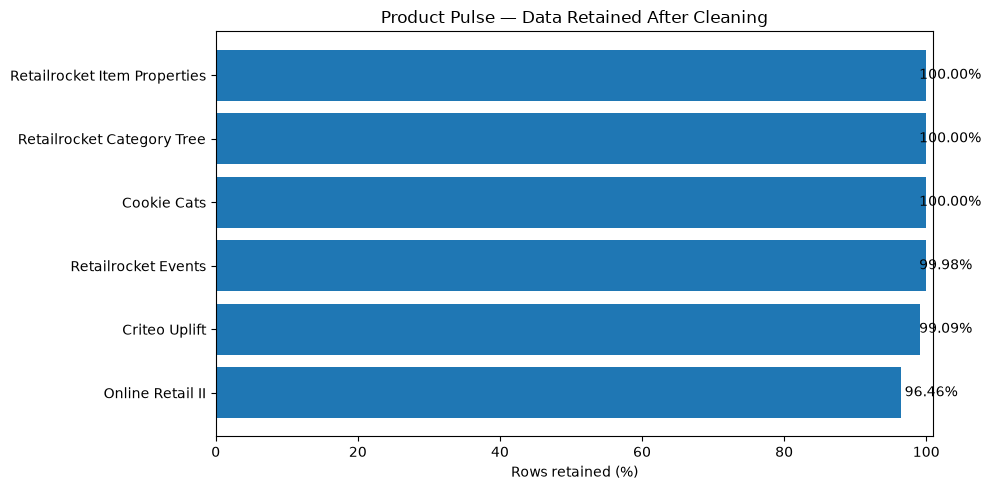

In [19]:

fig_retention, ax = plt.subplots(figsize=(10, 5))

plot_df = cleaning_summary.sort_values("pct_retained")

ax.barh(plot_df["dataset"], plot_df["pct_retained"])
ax.set_xlabel("Rows retained (%)")
ax.set_ylabel("")
ax.set_title("Product Pulse — Data Retained After Cleaning")
ax.set_xlim(0, 101)

for y, value in enumerate(plot_df["pct_retained"]):
    ax.text(min(value + 0.5, 99.0), y, f"{value:.2f}%", va="center")

fig_retention.tight_layout()
plt.show()



# 8. Save Notebook 02 results

This cell deliberately saves **only explicitly named compact result tables and figures**.

It does **not** scan `globals()`, so it cannot accidentally save raw or cleaned million-row datasets into `results/`.


In [20]:

# ============================================================
# SAVE NOTEBOOK 02 RESULTS
# ============================================================

TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RESULT_TABLES = {
    "input_file_check": file_check,
    "cleaning_summary": cleaning_summary,
    "validation_summary": validation_summary,
    "processed_outputs": processed_outputs,
}

RESULT_FIGURES = {
    "data_retention_after_cleaning": fig_retention,
}

saved_table_paths = []
saved_figure_paths = []

for name, table in RESULT_TABLES.items():
    path = TABLES_DIR / f"{name}.csv"
    table.to_csv(path, index=False)
    saved_table_paths.append(path)

for name, fig in RESULT_FIGURES.items():
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=200, bbox_inches="tight")
    saved_figure_paths.append(path)

print("=" * 68)
print("PRODUCT PULSE — NOTEBOOK 02 RESULTS SAVED")
print("=" * 68)

print(f"\nTables saved : {len(saved_table_paths)}")
for path in saved_table_paths:
    print(" -", path.relative_to(PROJECT_ROOT))

print(f"\nFigures saved: {len(saved_figure_paths)}")
for path in saved_figure_paths:
    print(" -", path.relative_to(PROJECT_ROOT))

print("\nProcessed datasets:")
print(PROCESSED_DIR)

print("\nResults directory:")
print(RESULTS_DIR)


PRODUCT PULSE — NOTEBOOK 02 RESULTS SAVED

Tables saved : 4
 - results/02_data_cleaning_and_validation/tables/input_file_check.csv
 - results/02_data_cleaning_and_validation/tables/cleaning_summary.csv
 - results/02_data_cleaning_and_validation/tables/validation_summary.csv
 - results/02_data_cleaning_and_validation/tables/processed_outputs.csv

Figures saved: 1
 - results/02_data_cleaning_and_validation/figures/data_retention_after_cleaning.png

Processed datasets:
/Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/02_cleaned

Results directory:
/Users/noopur/Desktop/resume_projects/ProductPulse/results/02_data_cleaning_and_validation
